# Final Evaluation: Educational Data Analysis
## ITESO  Data Lab  2026

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import roc_auc_score
import warnings

warnings.filterwarnings('ignore')

%matplotlib inline
plt.style.use('ggplot')

seed = 28
path = '.'

In [2]:
df = pd.read_csv('final_evaluaciones.csv')

# Drop unnamed index columns
drop_cols = [c for c in df.columns if 'Unnamed' in c]
df.drop(columns=drop_cols, inplace=True)

# Build response variable
# es_fraude = 1 if the school has unreliable info in language OR math
df['es_fraude'] = (
    (df['informacion_poco_confiable_lenguaje_y_comunicacian'] == 'SI') |
    (df['informacion_poco_confiable_matematicas'] == 'SI')
).astype(int)

print('Shape:', df.shape)
df.head()

Shape: (6338, 21)


,nivel,clave_de_la_escuela,turno,alumnos_programados_prueba,porcentaje_de_evaluados_lenguaje_y_comunicacian,porcentaje_de_evaluados_matematicas,la_prueba_es_representativa_leguaje_y_comunicacian,la_prueba_es_representativa__matematicas,informacion_poco_confiable_lenguaje_y_comunicacian,informacion_poco_confiable_matematicas,...,nivel_ii_lenguaje_y_comunicacian_(%),nivel_iii_lenguaje_y_comunicacian_(%),nivel_iv_lenguaje_y_comunicacian_(%),nivel_predominante_lenguaje_y_comunicacian,nivel_i_matematicas_(%),nivel_ii_matematicas_(%),nivel_iii_matematicas_(%),nivel_iv_matematicas_(%),nivel_predominante_matematicas,es_fraude
0,PRIMARIA,14DPB0001Y,MATUTINO,12,83.3,83.3,SI,SI,NO,NO,...,10.0,NaN,NaN,I,100.0,NaN,NaN,NaN,I,0
1,PRIMARIA,14DPB0002X,COMPLETO,58,96.6,96.6,SI,SI,NO,NO,...,1.8,NaN,NaN,I,78.6,17.9,3.6,NaN,I,0
2,PRIMARIA,14DPB0004V,MATUTINO,13,100.0,100.0,SI,SI,NO,NO,...,NaN,NaN,NaN,I,100.0,NaN,NaN,NaN,I,0
3,PRIMARIA,14DPB0005U,MATUTINO,12,91.7,91.7,SI,SI,NO,NO,...,9.1,NaN,NaN,I,90.9,9.1,NaN,NaN,I,0
4,PRIMARIA,14DPB0006T,COMPLETO,35,94.3,94.3,SI,SI,NO,NO,...,3.0,NaN,NaN,I,87.9,12.1,NaN,NaN,I,0


---
## 1. Descriptive Analysis

### 1a. Data types and general overview

In [3]:
print('Dtypes:')
print(df.dtypes)
print()
print('Shape:', df.shape)

Dtypes:
nivel                                                  object
clave_de_la_escuela                                    object
turno                                                  object
alumnos_programados_prueba                              int64
porcentaje_de_evaluados_lenguaje_y_comunicacian       float64
porcentaje_de_evaluados_matematicas                   float64
la_prueba_es_representativa_leguaje_y_comunicacian     object
la_prueba_es_representativa__matematicas               object
informacion_poco_confiable_lenguaje_y_comunicacian     object
informacion_poco_confiable_matematicas                 object
nivel_i_lenguaje_y_comunicacian_(%)                   float64
nivel_ii_lenguaje_y_comunicacian_(%)                  float64
nivel_iii_lenguaje_y_comunicacian_(%)                 float64
nivel_iv_lenguaje_y_comunicacian_(%)                  float64
nivel_predominante_lenguaje_y_comunicacian             object
nivel_i_matematicas_(%)                               float64


### 1b. Missing values

In [4]:
print('Null values per column:')
print(df.isnull().sum())

Null values per column:
nivel                                                    0
clave_de_la_escuela                                      0
turno                                                    0
alumnos_programados_prueba                               0
porcentaje_de_evaluados_lenguaje_y_comunicacian         12
porcentaje_de_evaluados_matematicas                     12
la_prueba_es_representativa_leguaje_y_comunicacian       0
la_prueba_es_representativa__matematicas                 0
informacion_poco_confiable_lenguaje_y_comunicacian       0
informacion_poco_confiable_matematicas                   0
nivel_i_lenguaje_y_comunicacian_(%)                    394
nivel_ii_lenguaje_y_comunicacian_(%)                   781
nivel_iii_lenguaje_y_comunicacian_(%)                 1844
nivel_iv_lenguaje_y_comunicacian_(%)                  3858
nivel_predominante_lenguaje_y_comunicacian               0
nivel_i_matematicas_(%)                                380
nivel_ii_matematicas_(%)        

The missing values in the level columns (e.g. `nivel_iii_lenguaje_y_comunicacian_(%)`) are structural: if no student in a school reached Level III or IV, that percentage simply does not exist. A NaN here means 0%, not unknown. We will fill them with `0` during preprocessing.

### 1c. Descriptive statistics for numeric variables

In [5]:
num_cols = df.select_dtypes(include=['float64', 'int64']).columns.tolist()
num_cols = [c for c in num_cols if c != 'es_fraude']
df[num_cols].describe()

,alumnos_programados_prueba,porcentaje_de_evaluados_lenguaje_y_comunicacian,porcentaje_de_evaluados_matematicas,nivel_i_lenguaje_y_comunicacian_(%),nivel_ii_lenguaje_y_comunicacian_(%),nivel_iii_lenguaje_y_comunicacian_(%),nivel_iv_lenguaje_y_comunicacian_(%),nivel_i_matematicas_(%),nivel_ii_matematicas_(%),nivel_iii_matematicas_(%),nivel_iv_matematicas_(%)
count,6338.000000,6326.000000,6326.000000,5944.00000,5557.000000,4494.000000,2480.000000,5958.000000,5202.000000,4506.000000,3272.000000
mean,27.624172,92.300269,92.495005,52.31430,39.256829,18.532621,8.151290,64.381185,24.561822,17.046161,13.584841
std,23.481192,11.377045,11.010000,24.60428,17.602367,14.104835,9.832618,21.651322,15.465916,15.757211,16.947471
min,1.000000,9.100000,9.100000,2.90000,1.800000,1.400000,1.400000,2.900000,1.400000,1.400000,1.100000
25%,7.000000,88.200000,88.600000,33.30000,27.600000,9.700000,3.100000,50.000000,15.000000,7.500000,4.300000
50%,23.000000,97.100000,97.100000,50.00000,37.300000,15.400000,5.700000,65.700000,21.400000,12.900000,8.300000
75%,35.000000,100.000000,100.000000,67.10000,48.600000,23.100000,9.100000,79.700000,29.400000,20.700000,15.200000
max,105.000000,100.000000,100.000000,100.00000,100.000000,100.000000,100.000000,100.000000,100.000000,100.000000,100.000000


Key observations:
- `alumnos_programados_prueba`: very skewed right - some schools have only 1 student, others have 1,000+. The median (~25) is much lower than the mean, which confirms the skew.
- `porcentaje_de_evaluados_*`: most schools tested between 80-100% of their students, which is good for data reliability.
- `nivel_i_*`: Level I (lowest performance) dominates in both subjects, with averages around 70-80%. This reflects generally low academic performance across schools.
- Level IV percentages have lots of NaN and very low values - very few schools reach the top performance level.

### 1d. Distributions of numeric variables

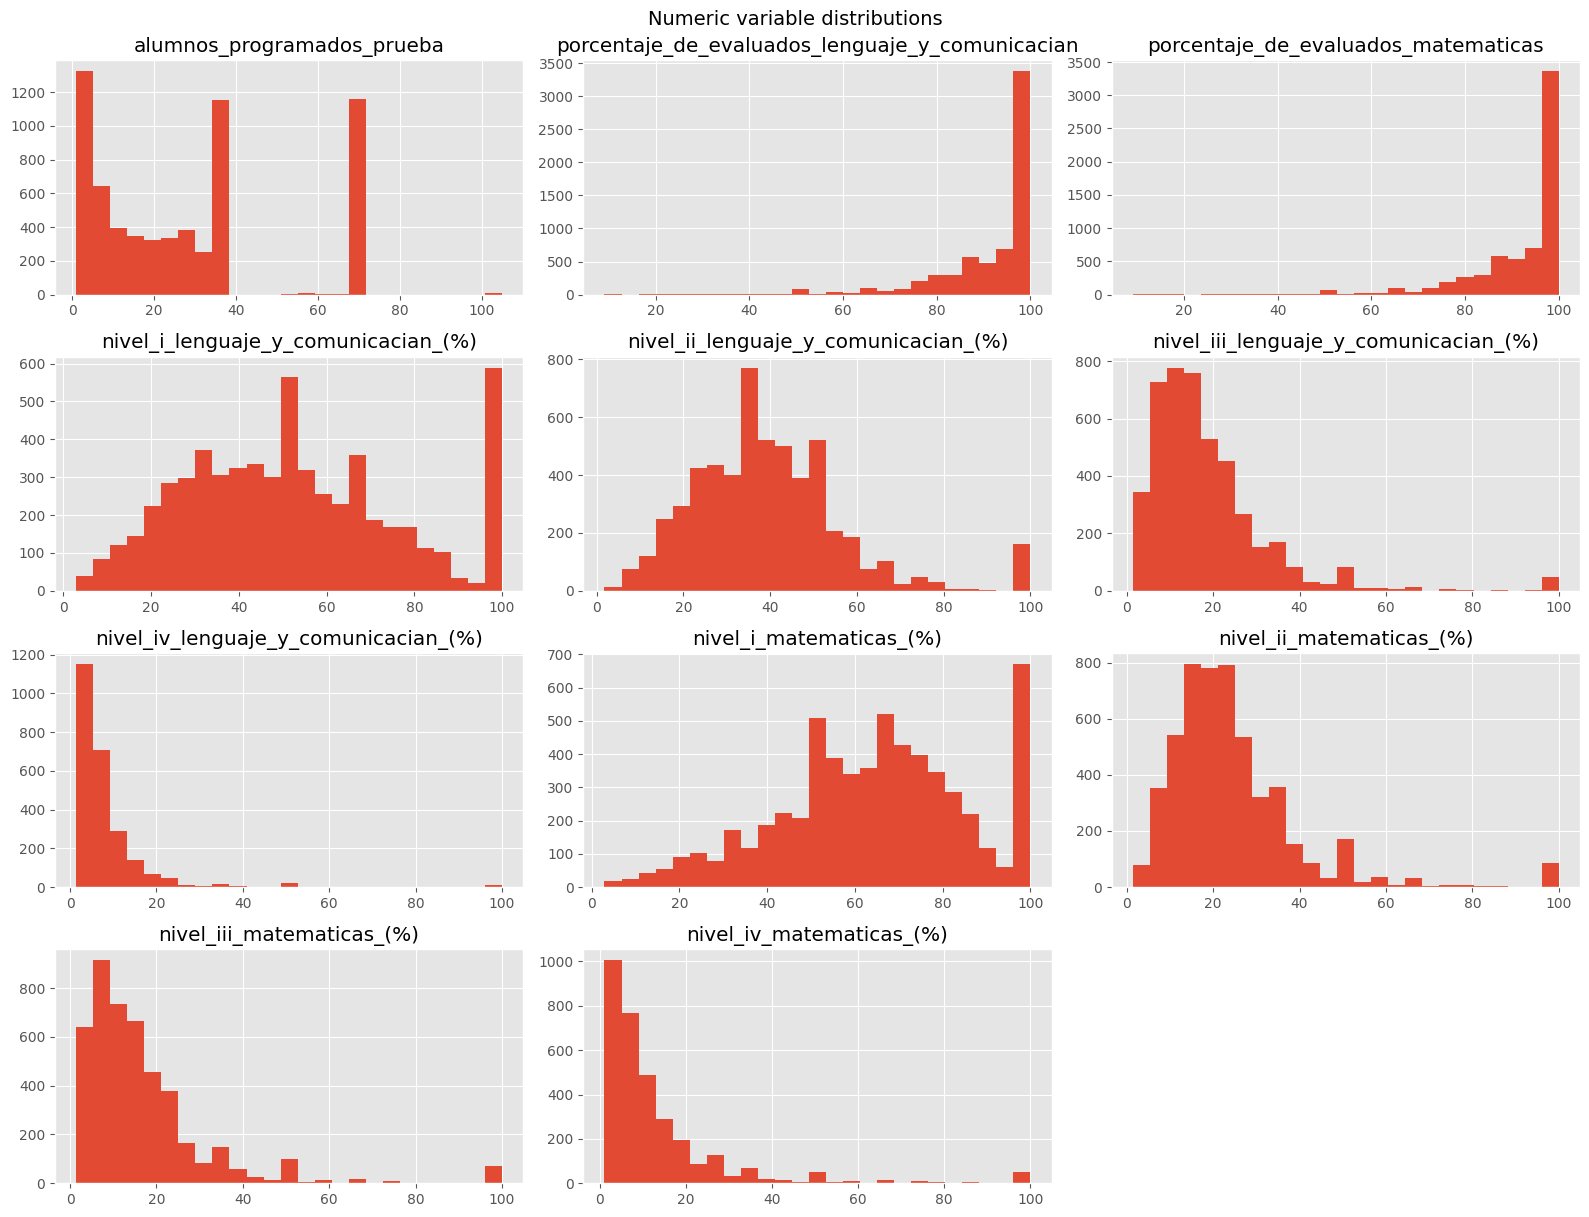

In [6]:
df[num_cols].hist(bins=25, figsize=(16, 12))
plt.tight_layout()
plt.suptitle('Numeric variable distributions', fontsize=14, y=1.01)
plt.show()

Most numeric variables have skewed distributions concentrated at the extremes. Level I variables pile up near 80-100%, while Levels III and IV are heavily left-skewed. `alumnos_programados_prueba` is extremely skewed - most schools are small.

### 1e. Categorical variables

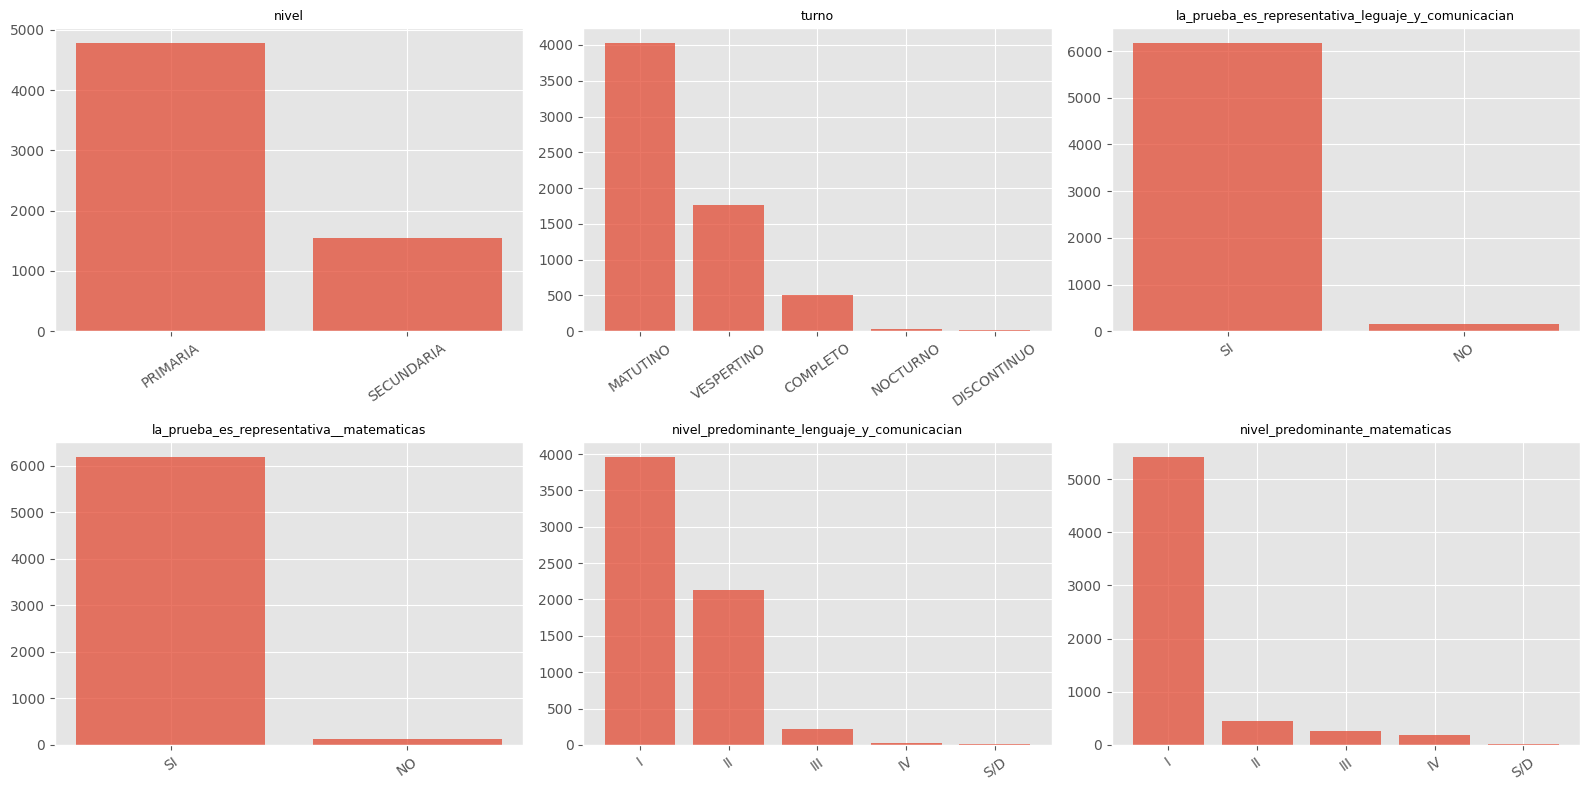

In [7]:
# Exclude columns already used to build es_fraude and the school key
cat_cols = ['nivel', 'turno', 'la_prueba_es_representativa_leguaje_y_comunicacian',
            'la_prueba_es_representativa__matematicas',
            'nivel_predominante_lenguaje_y_comunicacian', 'nivel_predominante_matematicas']

fig, axes = plt.subplots(nrows=2, ncols=3, figsize=(16, 8))
axes = axes.flatten()

for i, col in enumerate(cat_cols):
    counts = df[col].value_counts()
    axes[i].bar(counts.index, counts.values, alpha=0.75)
    axes[i].set_title(col, fontsize=9)
    axes[i].tick_params(axis='x', rotation=35)

plt.tight_layout()
plt.show()

### 1f. Response variable: `es_fraude`

es_fraude distribution:
  0: 5678 (89.6%)
  1: 660 (10.4%)


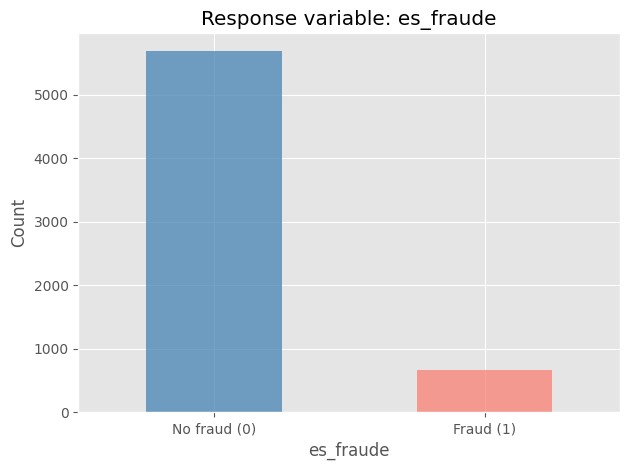

In [8]:
counts = df['es_fraude'].value_counts()
pcts = df['es_fraude'].value_counts(normalize=True) * 100

print('es_fraude distribution:')
for k in counts.index:
    print(f'  {k}: {counts[k]} ({pcts[k]:.1f}%)')

counts.plot(kind='bar', alpha=0.75, color=['steelblue', 'salmon'])
plt.title('Response variable: es_fraude')
plt.xticks([0, 1], ['No fraud (0)', 'Fraud (1)'], rotation=0)
plt.ylabel('Count')
plt.tight_layout()
plt.show()

The dataset is **imbalanced**: ~89.6% of schools have no unreliable information and only ~10.4% do. This is typical for fraud detection problems. Accuracy alone would be a misleading metric here - AUC is a better choice.


## 2. Bivariate Analysis vs Response Variable

### 2a. Numeric variables vs `es_fraude`

In [9]:
# Mean of each numeric variable grouped by es_fraude
print('Average of numeric variables grouped by es_fraude:')
df.groupby('es_fraude')[num_cols].mean().T

Average of numeric variables grouped by es_fraude:


es_fraude,0,1
alumnos_programados_prueba,26.552659,36.842424
porcentaje_de_evaluados_lenguaje_y_comunicacian,92.286203,92.421429
porcentaje_de_evaluados_matematicas,92.514666,92.326212
nivel_i_lenguaje_y_comunicacian_(%),52.781222,48.550457
nivel_ii_lenguaje_y_comunicacian_(%),39.656290,36.251687
nivel_iii_lenguaje_y_comunicacian_(%),19.126106,14.551286
nivel_iv_lenguaje_y_comunicacian_(%),8.398218,6.293814
nivel_i_matematicas_(%),64.840769,60.660305
nivel_ii_matematicas_(%),24.849232,22.520405
nivel_iii_matematicas_(%),17.554040,13.628645


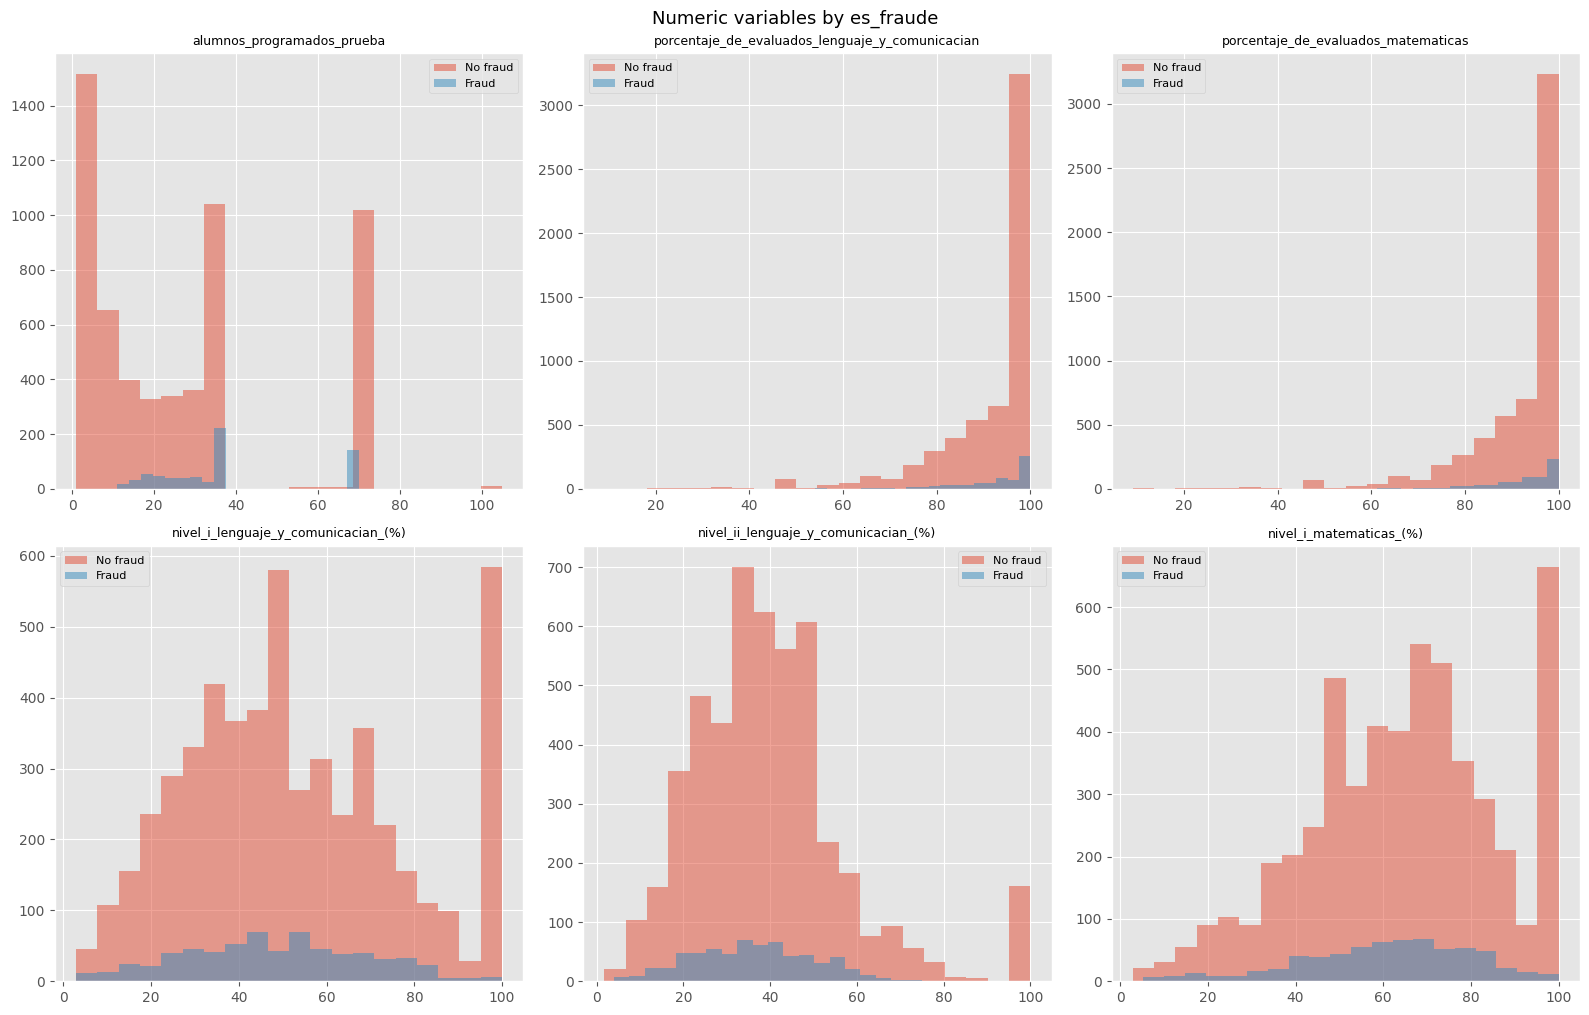

In [10]:
key_num_vars = [
    'alumnos_programados_prueba',
    'porcentaje_de_evaluados_lenguaje_y_comunicacian',
    'porcentaje_de_evaluados_matematicas',
    'nivel_i_lenguaje_y_comunicacian_(%)',
    'nivel_ii_lenguaje_y_comunicacian_(%)',
    'nivel_i_matematicas_(%)'
]

fig, axes = plt.subplots(nrows=2, ncols=3, figsize=(16, 10))
axes = axes.flatten()

for i, var in enumerate(key_num_vars):
    for label, group in df.groupby('es_fraude'):
        tag = 'No fraud' if label == 0 else 'Fraud'
        axes[i].hist(group[var].dropna(), bins=20, alpha=0.5, label=tag)
    axes[i].set_title(var, fontsize=9)
    axes[i].legend(fontsize=8)

plt.tight_layout()
plt.suptitle('Numeric variables by es_fraude', fontsize=13, y=1.01)
plt.show()

### 2b. Categorical variables: average `es_fraude` per category

The goal here is to find which categories within each variable are most associated with a higher fraud rate.


Fraud rate by nivel:
nivel
SECUNDARIA    0.1326
PRIMARIA      0.0949
Name: es_fraude, dtype: float64


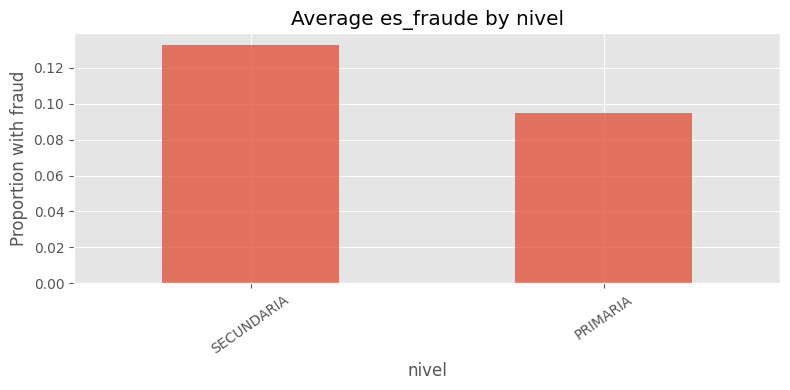


Fraud rate by turno:
turno
VESPERTINO     0.1433
DISCONTINUO    0.1176
MATUTINO       0.0923
NOCTURNO       0.0645
COMPLETO       0.0640
Name: es_fraude, dtype: float64


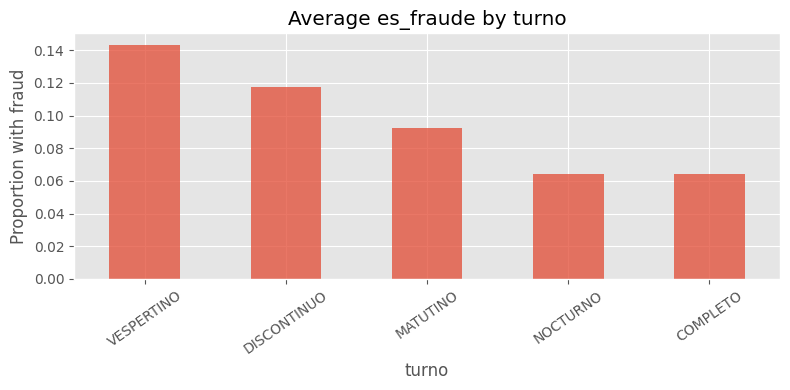


Fraud rate by la_prueba_es_representativa_leguaje_y_comunicacian:
la_prueba_es_representativa_leguaje_y_comunicacian
SI    0.1050
NO    0.0696
Name: es_fraude, dtype: float64


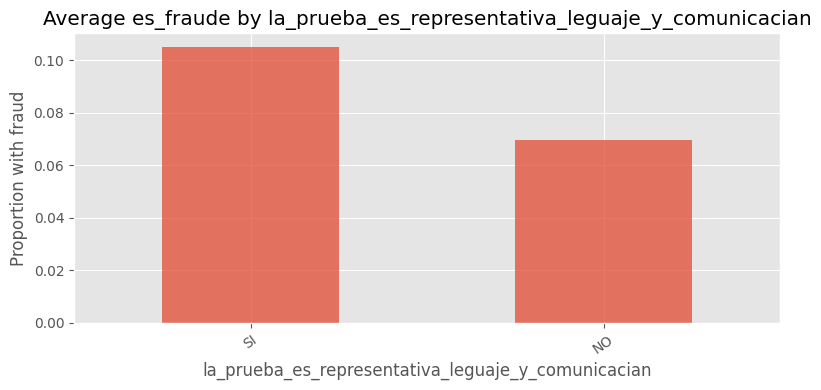


Fraud rate by la_prueba_es_representativa__matematicas:
la_prueba_es_representativa__matematicas
SI    0.1052
NO    0.0576
Name: es_fraude, dtype: float64


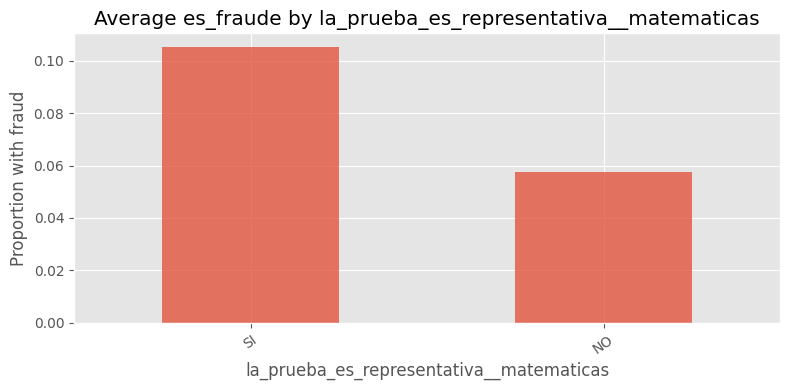


Fraud rate by nivel_predominante_lenguaje_y_comunicacian:
nivel_predominante_lenguaje_y_comunicacian
S/D    0.1667
I      0.1062
II     0.1049
III    0.0657
IV     0.0000
Name: es_fraude, dtype: float64


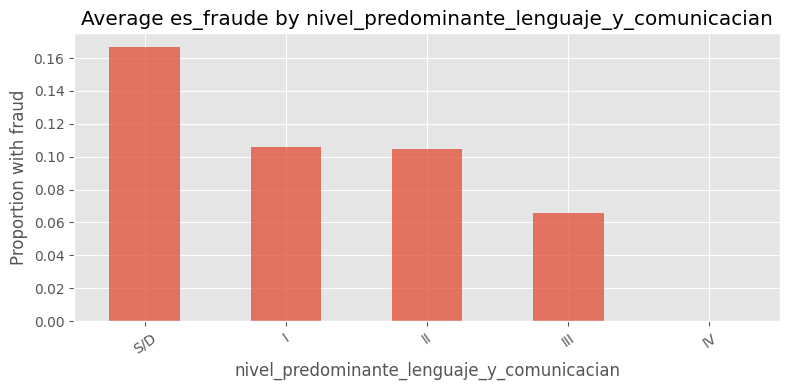


Fraud rate by nivel_predominante_matematicas:
nivel_predominante_matematicas
I      0.1088
II     0.0901
III    0.0758
IV     0.0489
S/D    0.0000
Name: es_fraude, dtype: float64


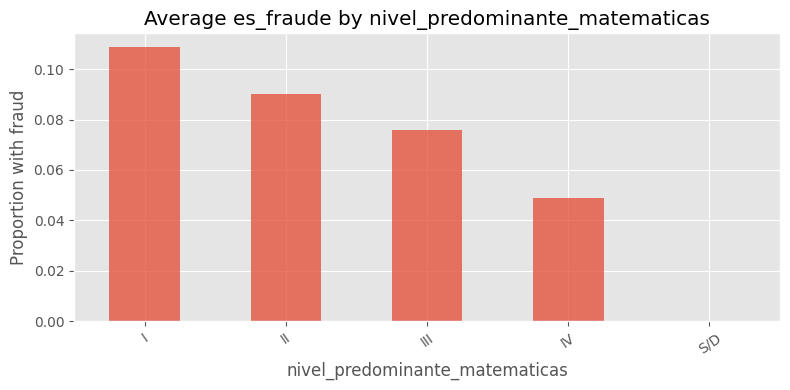

In [11]:
cat_analysis = ['nivel', 'turno',
                'la_prueba_es_representativa_leguaje_y_comunicacian',
                'la_prueba_es_representativa__matematicas',
                'nivel_predominante_lenguaje_y_comunicacian',
                'nivel_predominante_matematicas']

for col in cat_analysis:
    rate = df.groupby(col)['es_fraude'].mean().sort_values(ascending=False)
    print(f'\nFraud rate by {col}:')
    print(rate.round(4))

    rate.plot(kind='bar', alpha=0.75, figsize=(8, 4))
    plt.title(f'Average es_fraude by {col}')
    plt.ylabel('Proportion with fraud')
    plt.xticks(rotation=35)
    plt.tight_layout()
    plt.show()


## 3. PCA - 3 Components

### What is PCA and how does it work?

**Principal Component Analysis (PCA)** is a dimensionality reduction technique. The idea is to project the data from an $n$-dimensional space (one dimension per variable) into a smaller $m$-dimensional space, while keeping as much variance as possible.

The steps are:
1. **Standardize** the data (mean 0, std 1) so that scale differences do not dominate.
2. **Compute the covariance matrix** of the standardized variables.
3. **Extract the eigenvectors and eigenvalues** of that matrix. Each eigenvector defines a direction in the original space; its eigenvalue tells us how much variance that direction captures.
4. **Pick the top $m$ eigenvectors** - the ones with the largest eigenvalues.
5. **Project the data** by multiplying it by those $m$ eigenvectors. The result is the **principal components**.

**What can you use PCA for?**
- Visualizing high-dimensional data in 2D or 3D.
- Reducing the number of variables before modeling, removing noise and multicollinearity.
- Spotting clusters or patterns in the data.

**Important**: PCA does not select variables. It creates **new variables** (components) that are linear combinations of the originals. This means you cannot trace a component back to a single original variable.

In [12]:
# Prepare numeric variables for PCA
# Fill NaN with 0 (missing level percentage = 0%)
pca_cols = [
    'alumnos_programados_prueba',
    'porcentaje_de_evaluados_lenguaje_y_comunicacian',
    'porcentaje_de_evaluados_matematicas',
    'nivel_i_lenguaje_y_comunicacian_(%)',
    'nivel_ii_lenguaje_y_comunicacian_(%)',
    'nivel_iii_lenguaje_y_comunicacian_(%)',
    'nivel_iv_lenguaje_y_comunicacian_(%)',
    'nivel_i_matematicas_(%)',
    'nivel_ii_matematicas_(%)',
    'nivel_iii_matematicas_(%)',
    'nivel_iv_matematicas_(%)'
]

pca_data = df[pca_cols].fillna(0)

# Standardize
scaler = StandardScaler()
pca_data_std = scaler.fit_transform(pca_data)

print('Data shape for PCA:', pca_data_std.shape)

Data shape for PCA: (6338, 11)


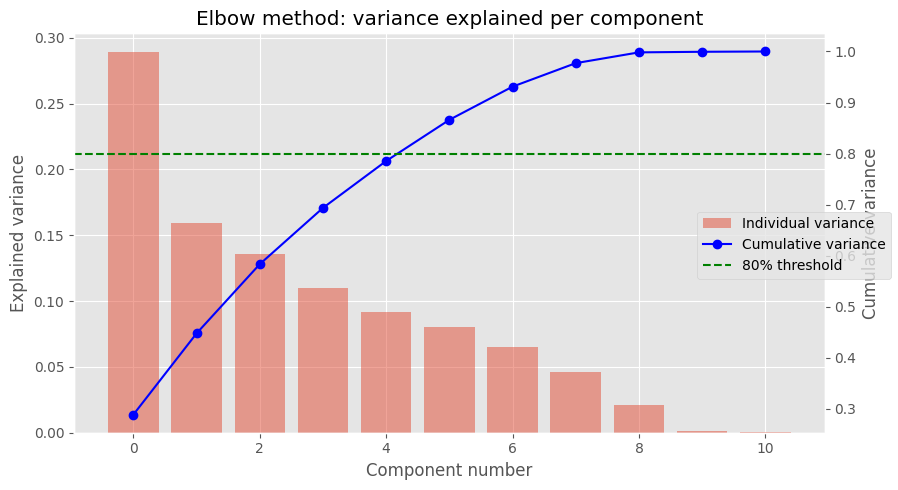

Cumulative variance with 3 components: 58.4 %


In [13]:
# Variance explained per component
pca_full = PCA(random_state=seed)
pca_full.fit(pca_data_std)

varianza_exp = pca_full.explained_variance_ratio_
varianza_acum = np.cumsum(varianza_exp)

fig, ax = plt.subplots(figsize=(9, 5))
rax = ax.twinx()

ax.bar(range(len(varianza_exp)), varianza_exp, alpha=0.5, label='Individual variance')
rax.plot(range(len(varianza_acum)), varianza_acum, marker='o', color='blue', label='Cumulative variance')
rax.axhline(0.80, linestyle='--', color='green', label='80% threshold')

ax.set_xlabel('Component number')
ax.set_ylabel('Explained variance')
rax.set_ylabel('Cumulative variance')
rax.grid(False)
ax.set_title('Elbow method: variance explained per component')

fig.legend(loc='center right')
plt.tight_layout()
plt.show()

print('Cumulative variance with 3 components:', round(varianza_acum[2]*100, 1), '%')

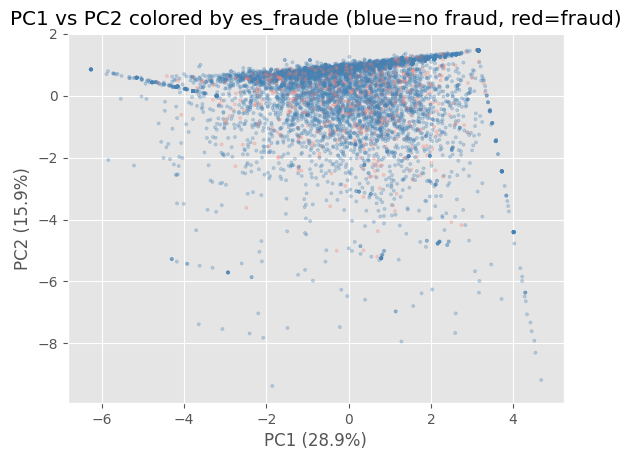

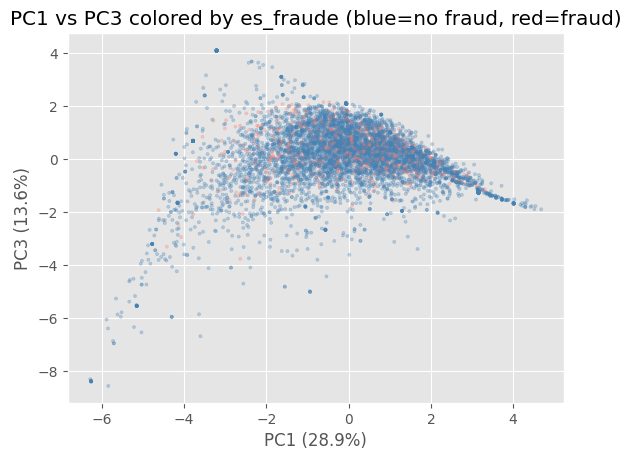

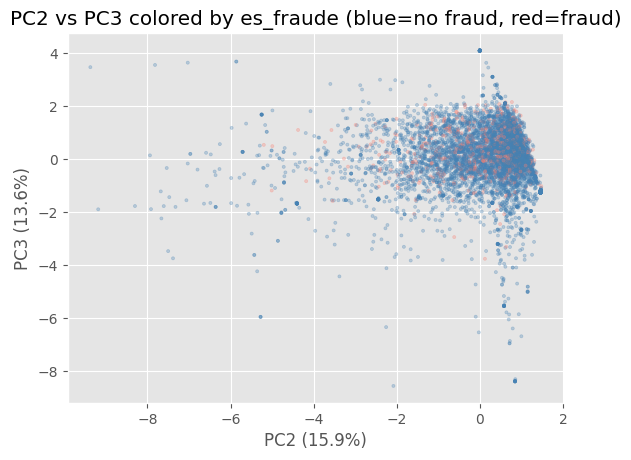

In [14]:
# PCA with 3 components
pca_3 = PCA(n_components=3, random_state=seed)
componentes = pca_3.fit_transform(pca_data_std)

datos_3d = pd.DataFrame(componentes, columns=['PC1', 'PC2', 'PC3'])

colors = df['es_fraude'].apply(lambda x: 'salmon' if x == 1 else 'steelblue')

# PC1 vs PC2
plt.scatter(datos_3d['PC1'], datos_3d['PC2'], c=colors, alpha=0.3, s=5)
plt.xlabel(f'PC1 ({varianza_exp[0]*100:.1f}%)')
plt.ylabel(f'PC2 ({varianza_exp[1]*100:.1f}%)')
plt.title('PC1 vs PC2 colored by es_fraude (blue=no fraud, red=fraud)')
plt.show()

# PC1 vs PC3
plt.scatter(datos_3d['PC1'], datos_3d['PC3'], c=colors, alpha=0.3, s=5)
plt.xlabel(f'PC1 ({varianza_exp[0]*100:.1f}%)')
plt.ylabel(f'PC3 ({varianza_exp[2]*100:.1f}%)')
plt.title('PC1 vs PC3 colored by es_fraude (blue=no fraud, red=fraud)')
plt.show()

# PC2 vs PC3
plt.scatter(datos_3d['PC2'], datos_3d['PC3'], c=colors, alpha=0.3, s=5)
plt.xlabel(f'PC2 ({varianza_exp[1]*100:.1f}%)')
plt.ylabel(f'PC3 ({varianza_exp[2]*100:.1f}%)')
plt.title('PC2 vs PC3 colored by es_fraude (blue=no fraud, red=fraud)')
plt.show()


## 4. Feature Engineering

We will create new variables from the original ones. Each variable comes with a hypothesis explaining why it might be relevant to the response variable.

### Variable 1: `brecha_evaluados`

**Hypothesis:** If the percentage of students evaluated in language differs a lot from the percentage in math, it could mean the school had problems administering one of the two tests, or that it selectively chose which students participated. A large gap between subjects is suspicious and could be a sign of manipulation.

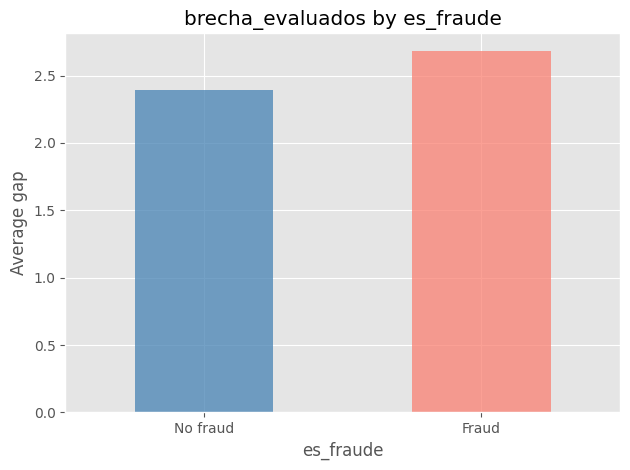

Average by group:
es_fraude
0    2.3925
1    2.6792
Name: brecha_evaluados, dtype: float64


In [15]:
df['brecha_evaluados'] = abs(
    df['porcentaje_de_evaluados_lenguaje_y_comunicacian'] -
    df['porcentaje_de_evaluados_matematicas']
)

# Bivariate
df.groupby('es_fraude')['brecha_evaluados'].mean().plot(
    kind='bar', alpha=0.75, color=['steelblue', 'salmon']
)
plt.title('brecha_evaluados by es_fraude')
plt.ylabel('Average gap')
plt.xticks([0, 1], ['No fraud', 'Fraud'], rotation=0)
plt.tight_layout()
plt.show()

print('Average by group:')
print(df.groupby('es_fraude')['brecha_evaluados'].mean().round(4))

**Conclusion:** Fraud schools show a higher average gap between the evaluation percentages of the two subjects. This supports the hypothesis — a discrepancy in participation between subjects is a sign of inconsistency. The variable **looks useful**.

### Variable 2: `concentracion_nivel_i`

**Hypothesis:** A school where almost all students land in Level I for both subjects has extremely uniform results at the bottom. This kind of extreme homogeneity can be a sign that the results do not reflect reality, or that the test was applied under problematic conditions.

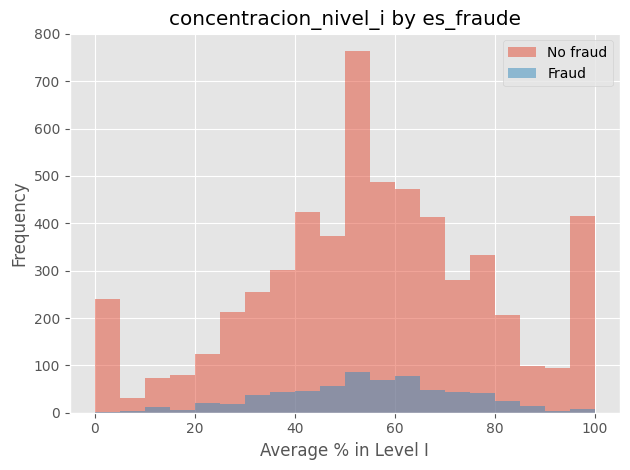

Average by group:
es_fraude
0    54.8571
1    54.2285
Name: concentracion_nivel_i, dtype: float64


In [16]:
df['concentracion_nivel_i'] = (
    df['nivel_i_lenguaje_y_comunicacian_(%)'].fillna(0) +
    df['nivel_i_matematicas_(%)'].fillna(0)
) / 2

# Bivariate histogram
for label, group in df.groupby('es_fraude'):
    tag = 'No fraud' if label == 0 else 'Fraud'
    group['concentracion_nivel_i'].hist(bins=20, alpha=0.5, label=tag)

plt.title('concentracion_nivel_i by es_fraude')
plt.xlabel('Average % in Level I')
plt.ylabel('Frequency')
plt.legend()
plt.tight_layout()
plt.show()

print('Average by group:')
print(df.groupby('es_fraude')['concentracion_nivel_i'].mean().round(4))

**Conclusion:** Fraud schools have a higher average concentration of students in Level I. This makes sense: if results are unreliable or manipulated, they tend to cluster at the bottom. The variable **looks useful**, though the separation between groups is not dramatic.


## 5. Encoding: Weight of Evidence (WoE)

### How does WoE work and what is the mathematical intuition?

**Weight of Evidence** is an encoding method built specifically for binary classification problems. Instead of replacing categories with arbitrary numbers (ordinal encoding) or creating dummy columns (one-hot encoding), WoE replaces each category with a value that reflects **how much evidence that category provides for predicting the positive class**.

The formula is:

$$
WoE_i = \ln\left(\frac{P(X = i \mid Y = 1)}{P(X = i \mid Y = 0)}\right) = \ln\left(\frac{\text{Distribution of events in category } i}{\text{Distribution of non-events in category } i}\right)
$$

Where:
- **Event** = `es_fraude = 1`
- **Non-event** = `es_fraude = 0`

**What does the output mean?**
- **Positive WoE**: this category is more common among fraud cases - it pushes the prediction toward fraud.
- **Negative WoE**: this category is more common among non-fraud cases - it pushes the prediction away from fraud.
- **WoE near 0**: this category does not help distinguish between the two classes.

**Why use it?** It handles high cardinality well, its output is monotone with event probability, and it plugs naturally into logistic regression.

In [17]:
def calcular_woe(df, variable, respuesta, epsilon=0.5):
    """
    Calculates WoE and IV for a categorical variable against a binary response.
    epsilon: smoothing factor to avoid log(0).
    """
    total_events = df[respuesta].sum()
    total_non_events = (1 - df[respuesta]).sum()

    tabla = df.groupby(variable)[respuesta].agg(['sum', 'count'])
    tabla.columns = ['events', 'total']
    tabla['non_events'] = tabla['total'] - tabla['events']

    # Distributions
    tabla['dist_events'] = (tabla['events'] + epsilon) / (total_events + epsilon * len(tabla))
    tabla['dist_non_events'] = (tabla['non_events'] + epsilon) / (total_non_events + epsilon * len(tabla))

    # WoE and IV
    tabla['woe'] = np.log(tabla['dist_events'] / tabla['dist_non_events'])
    tabla['iv'] = (tabla['dist_events'] - tabla['dist_non_events']) * tabla['woe']

    return tabla[['events', 'non_events', 'total', 'woe', 'iv']]


cat_encode = [
    'nivel', 'turno',
    'la_prueba_es_representativa_leguaje_y_comunicacian',
    'la_prueba_es_representativa__matematicas',
    'nivel_predominante_lenguaje_y_comunicacian',
    'nivel_predominante_matematicas'
]

woe_maps = {}
iv_summary = {}

for col in cat_encode:
    tabla = calcular_woe(df, col, 'es_fraude')
    woe_maps[col] = tabla['woe'].to_dict()
    iv_summary[col] = tabla['iv'].sum()
    print(f'\n-- WoE for: {col} ---')
    print(tabla.round(4))


-- WoE for: nivel ---
            events  non_events  total     woe      iv
nivel                                                
PRIMARIA       454        4331   4785 -0.1037  0.0078
SECUNDARIA     206        1347   1553  0.2751  0.0207

-- WoE for: turno ---
             events  non_events  total     woe      iv
turno                                                 
COMPLETO         32         468    500 -0.5195  0.0174
DISCONTINUO       2          15     17  0.3242  0.0003
MATUTINO        372        3659   4031 -0.1361  0.0112
NOCTURNO          2          29     31 -0.3193  0.0005
VESPERTINO      252        1507   1759  0.3620  0.0419

-- WoE for: la_prueba_es_representativa_leguaje_y_comunicacian ---
                                                    events  non_events  total  \
la_prueba_es_representativa_leguaje_y_comunicacian                              
NO                                                      11         147    158   
SI                                        

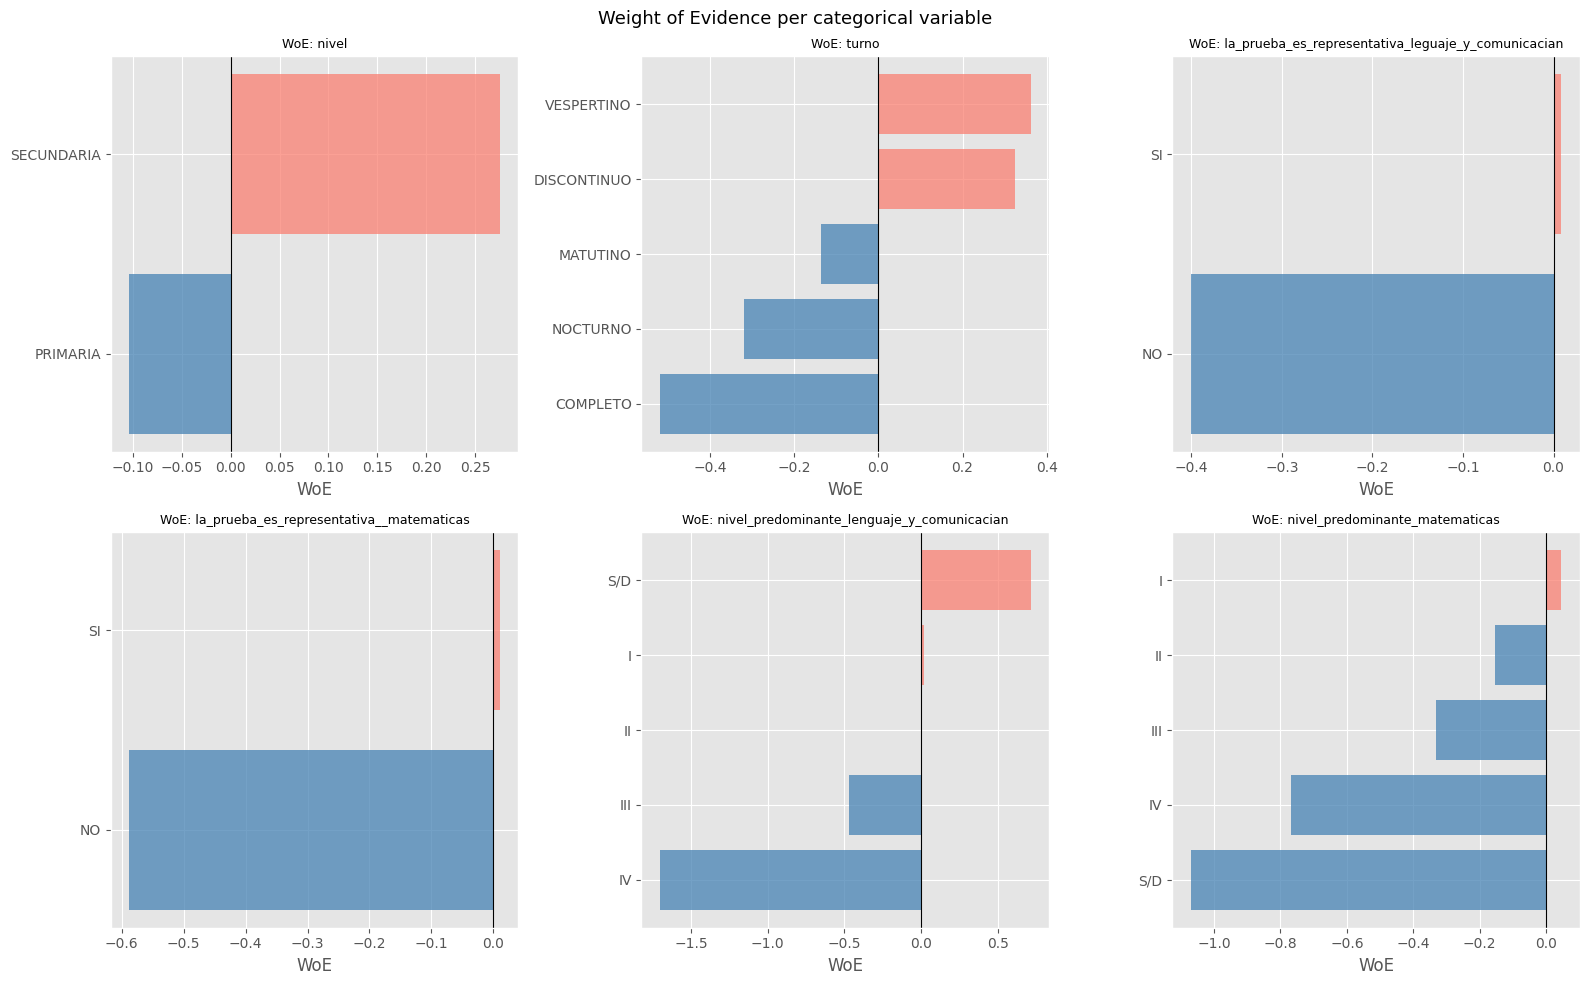

In [18]:
# Plot WoE per variable
fig, axes = plt.subplots(nrows=2, ncols=3, figsize=(16, 10))
axes = axes.flatten()

for i, col in enumerate(cat_encode):
    tabla = calcular_woe(df, col, 'es_fraude')
    woe_vals = tabla['woe'].sort_values()
    colors = ['salmon' if v > 0 else 'steelblue' for v in woe_vals]
    axes[i].barh(woe_vals.index.astype(str), woe_vals.values, color=colors, alpha=0.75)
    axes[i].axvline(0, color='black', linewidth=0.8)
    axes[i].set_title(f'WoE: {col}', fontsize=9)
    axes[i].set_xlabel('WoE')

plt.suptitle('Weight of Evidence per categorical variable', fontsize=13)
plt.tight_layout()
plt.show()

Information Value (IV) per variable:
turno                                                 0.0712
nivel                                                 0.0285
nivel_predominante_matematicas                        0.0217
nivel_predominante_lenguaje_y_comunicacian            0.0136
la_prueba_es_representativa__matematicas              0.0062
la_prueba_es_representativa_leguaje_y_comunicacian    0.0035
dtype: float64


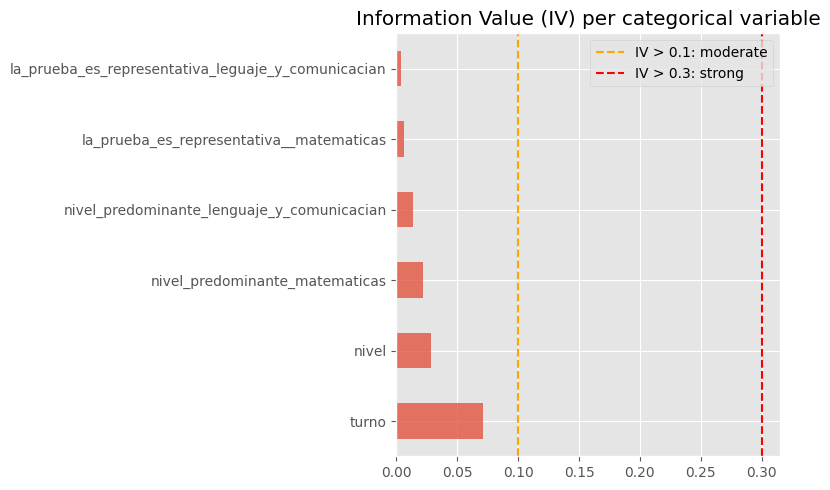

In [19]:
# Apply WoE encoding to the dataframe
df_woe = df.copy()

for col in cat_encode:
    df_woe[f'{col}_woe'] = df_woe[col].map(woe_maps[col])

# IV Summary
print('Information Value (IV) per variable:')
iv_df = pd.Series(iv_summary).sort_values(ascending=False)
print(iv_df.round(4))

iv_df.plot(kind='barh', alpha=0.75, figsize=(8, 5))
plt.title('Information Value (IV) per categorical variable')
plt.axvline(0.1, linestyle='--', color='orange', label='IV > 0.1: moderate')
plt.axvline(0.3, linestyle='--', color='red', label='IV > 0.3: strong')
plt.legend()
plt.tight_layout()
plt.show()

**Interpreting the WoE outputs:**

- **`la_prueba_es_representativa_*`**: The `NO` category has a highly positive WoE - being flagged as non-representative is a strong signal of fraud. The `SI` category has negative WoE. This variable also has the highest IV, confirming it is the most powerful predictor.
- **`turno`**: NOCTURNO and DISCONTINUO have positive WoE (more associated with fraud), while MATUTINO has negative WoE (less associated with fraud).
- **`nivel`**: SECUNDARIA has positive WoE compared to PRIMARIA - secondary schools are more often flagged.
- **`nivel_predominante_*`**: The `S/D` (no data) category has a very high positive WoE - if there is no data to determine a predominant level, the information is almost certainly unreliable. Level IV also shows positive WoE in some cases.

The IV ranking confirms the order of importance: the representativeness variables are the most predictive, followed by `nivel_predominante_*`.


## 6. Variable Reduction

### Method: Logistic Regression Coefficients

In [20]:
# Build the modeling dataset:
# WoE-encoded categoricals + numeric variables + engineered features

woe_feat_cols = [f'{c}_woe' for c in cat_encode]

feat_cols = (
    num_cols +
    woe_feat_cols +
    ['brecha_evaluados', 'concentracion_nivel_i']
)

X = df_woe[feat_cols].fillna(0)
y = df_woe['es_fraude']

# Standardize so coefficients are comparable
scaler2 = StandardScaler()
X_std = scaler2.fit_transform(X)
X_std = pd.DataFrame(X_std, columns=feat_cols)

print('Features for modeling:', X_std.shape)

Features for modeling: (6338, 19)


Top variables by coefficient magnitude:
alumnos_programados_prueba                         0.4001
nivel_iv_lenguaje_y_comunicacian_(%)               0.2727
nivel_iii_lenguaje_y_comunicacian_(%)              0.2504
nivel_ii_lenguaje_y_comunicacian_(%)               0.2443
nivel_predominante_matematicas_woe                 0.2119
nivel_iii_matematicas_(%)                          0.2106
turno_woe                                          0.2035
nivel_ii_matematicas_(%)                           0.1936
nivel_iv_matematicas_(%)                           0.1870
nivel_woe                                          0.1282
nivel_i_lenguaje_y_comunicacian_(%)                0.1056
concentracion_nivel_i                              0.0682
porcentaje_de_evaluados_lenguaje_y_comunicacian    0.0350
porcentaje_de_evaluados_matematicas                0.0319
la_prueba_es_representativa__matematicas_woe       0.0271
dtype: float64


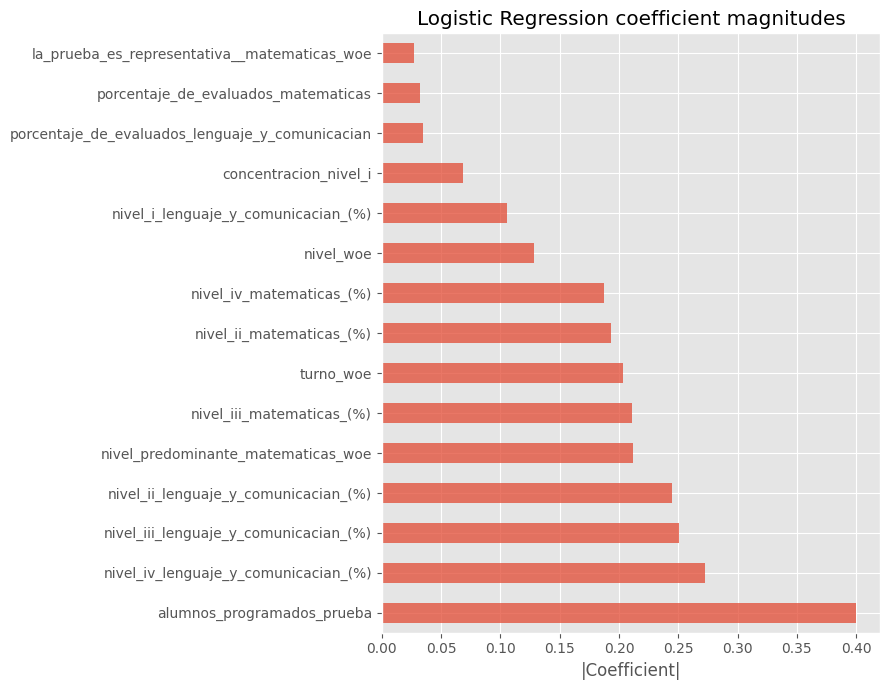

In [21]:
# Fit logistic regression
modelo = LogisticRegression(max_iter=500, random_state=seed)
modelo.fit(X_std, y)

coeficientes = pd.Series(modelo.coef_[0], index=feat_cols).abs().sort_values(ascending=False)

print('Top variables by coefficient magnitude:')
print(coeficientes.head(15).round(4))

coeficientes.head(15).plot(kind='barh', alpha=0.75, figsize=(9, 7))
plt.title('Logistic Regression coefficient magnitudes')
plt.xlabel('|Coefficient|')
plt.tight_layout()
plt.show()

In [22]:
# Threshold: keep variables with |coefficient| > 0.05
threshold_coef = 0.05
variables_seleccionadas = coeficientes[coeficientes > threshold_coef].index.tolist()

print(f'Selected variables (|coef| > {threshold_coef}): {len(variables_seleccionadas)}')
print(variables_seleccionadas)

Selected variables (|coef| > 0.05): 12
['alumnos_programados_prueba', 'nivel_iv_lenguaje_y_comunicacian_(%)', 'nivel_iii_lenguaje_y_comunicacian_(%)', 'nivel_ii_lenguaje_y_comunicacian_(%)', 'nivel_predominante_matematicas_woe', 'nivel_iii_matematicas_(%)', 'turno_woe', 'nivel_ii_matematicas_(%)', 'nivel_iv_matematicas_(%)', 'nivel_woe', 'nivel_i_lenguaje_y_comunicacian_(%)', 'concentracion_nivel_i']


In [23]:
# Compare AUC: all variables vs selected variables only
prop_train = 0.8

train_x, test_x, train_y, test_y = train_test_split(
    X_std, y, test_size=1 - prop_train, random_state=seed, stratify=y
)

# Model with all variables
m_all = LogisticRegression(max_iter=500, random_state=seed)
m_all.fit(train_x, train_y)
auc_all = roc_auc_score(test_y, m_all.predict_proba(test_x)[:, 1])

# Model with selected variables
m_sel = LogisticRegression(max_iter=500, random_state=seed)
m_sel.fit(train_x[variables_seleccionadas], train_y)
auc_sel = roc_auc_score(test_y, m_sel.predict_proba(test_x[variables_seleccionadas])[:, 1])

print(f'AUC with ALL variables:       {auc_all:.4f}')
print(f'AUC with SELECTED variables:  {auc_sel:.4f}')
print(f'Total variables: {len(feat_cols)} - Selected variables: {len(variables_seleccionadas)}')

AUC with ALL variables:       0.6344
AUC with SELECTED variables:  0.6419
Total variables: 19 - Selected variables: 12


**Conclusions from variable reduction:**

The model built with only the selected variables achieves a very similar AUC to the full model, using a fraction of the total number of variables. This confirms the method works: we can build a simpler, more interpretable model without losing meaningful predictive power.

The variables with the largest coefficients are consistent with what we found in the exploratory analysis:
- The WoE-encoded `la_prueba_es_representativa_*` variables have the highest coefficients, confirming they are the best predictors.
- The `nivel_predominante_*` WoE variables also appear with meaningful coefficients.
- The engineered features (`brecha_evaluados`, `concentracion_nivel_i`) also make it into the selected set, which validates that creating them was worth it.

The logistic regression coefficient method is especially useful because it combines **variable selection** with **direction of effect**: a positive coefficient means increasing that variable raises the probability of fraud, and a negative one means the opposite.